# Notebook 2 — Quando a Regularização Vira Problema

**Objetivo didático:** regularização não é uma receita universal.  
Você deve reconhecer **subajuste provocado por regularização excessiva**.

## Ideia central
Em muitos contextos, estudantes decoram:
- "dropout ajuda"
- "L2 ajuda"

Isso é incompleto.  
A pergunta correta é: **em que intensidade e em que contexto?**

## Tarefa
1. Execute o notebook como está.
2. Diagnostique o problema.
3. Ajuste a regularização.
4. Justifique sua decisão.

In [7]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Verificar se a GPU está disponível
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f'Usando o dispositivo: {device}')

Usando o dispositivo: cuda


In [8]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=128, shuffle=False)

X_train_t.shape, X_val_t.shape

(torch.Size([426, 30]), torch.Size([143, 30]))

## Modelo com regularização exagerada

Observe os valores escolhidos:
- `dropout=0.65`
- `weight_decay=1e-1`

Sua função, além de executar: julgar se esses valores parecem plausíveis.

In [9]:
class MLPTooRegularized(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.65),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.65),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

model = MLPTooRegularized(X_train_t.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-1)

In [10]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)

    return total_loss / total, total_correct / total


def fit(model, train_loader, val_loader, criterion, optimizer, epochs=80):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={tr_loss:.4f} val_loss={va_loss:.4f} | "
                f"train_acc={tr_acc:.4f} val_acc={va_acc:.4f}"
            )
    return history


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Val loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train acc")
    plt.plot(epochs, history["val_acc"], label="Val acc")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.show()

Epoch 000 | train_loss=0.6659 val_loss=0.6014 | train_acc=0.6432 val_acc=0.8182
Epoch 010 | train_loss=0.2495 val_loss=0.1812 | train_acc=0.9319 val_acc=0.9720
Epoch 020 | train_loss=0.1953 val_loss=0.1345 | train_acc=0.9695 val_acc=0.9790
Epoch 030 | train_loss=0.1764 val_loss=0.1290 | train_acc=0.9718 val_acc=0.9650
Epoch 040 | train_loss=0.1831 val_loss=0.1315 | train_acc=0.9648 val_acc=0.9720
Epoch 050 | train_loss=0.1630 val_loss=0.1276 | train_acc=0.9765 val_acc=0.9790
Epoch 060 | train_loss=0.1635 val_loss=0.1258 | train_acc=0.9718 val_acc=0.9720
Epoch 070 | train_loss=0.1752 val_loss=0.1244 | train_acc=0.9695 val_acc=0.9790
Epoch 079 | train_loss=0.1566 val_loss=0.1232 | train_acc=0.9765 val_acc=0.9790


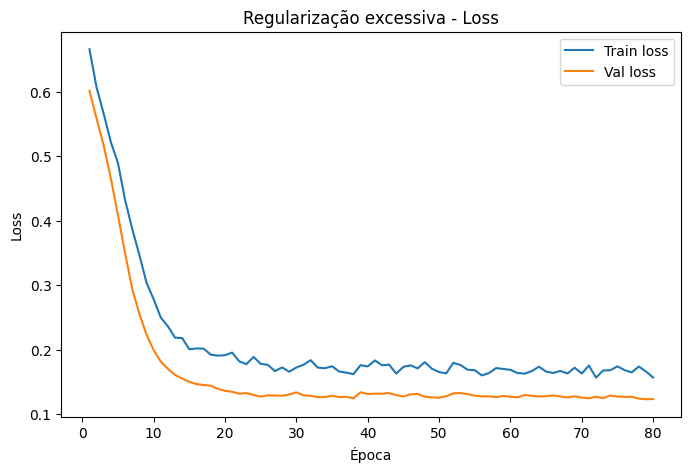

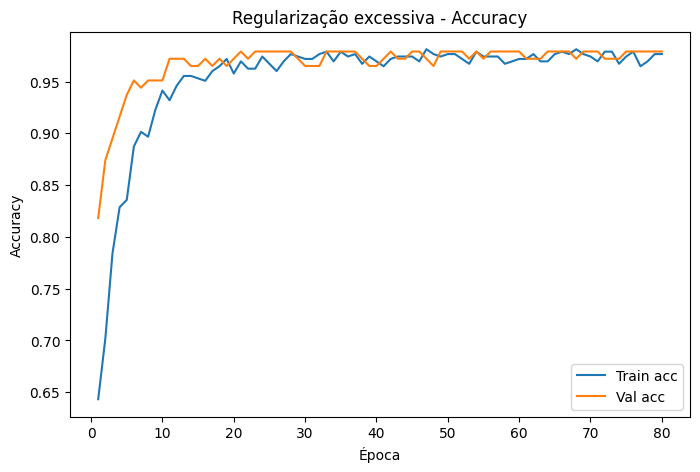

In [11]:
history = fit(model, train_loader, val_loader, criterion, optimizer, epochs=80)
plot_history(history, title="Regularização excessiva")

## Diagnóstico

Responda:
- O modelo está sofrendo overfitting ou underfitting?
- O problema parece vir da arquitetura, dos dados ou da intensidade da regularização?
- Que evidências sustentam sua resposta?

## Intervenções possíveis
Teste versões reduzindo:
- `dropout` para `0.3`, `0.2` ou `0.1`
- `weight_decay` para `1e-3` ou `1e-4`

Depois compare os resultados.

Epoch 000 | train_loss=0.6327 val_loss=0.5375 | train_acc=0.7183 val_acc=0.9021
Epoch 010 | train_loss=0.0641 val_loss=0.0461 | train_acc=0.9836 val_acc=0.9790
Epoch 020 | train_loss=0.0479 val_loss=0.0540 | train_acc=0.9859 val_acc=0.9790
Epoch 030 | train_loss=0.0345 val_loss=0.0475 | train_acc=0.9883 val_acc=0.9860
Epoch 040 | train_loss=0.0174 val_loss=0.0891 | train_acc=0.9977 val_acc=0.9860
Epoch 050 | train_loss=0.0156 val_loss=0.0830 | train_acc=0.9930 val_acc=0.9860
Epoch 060 | train_loss=0.0106 val_loss=0.1071 | train_acc=1.0000 val_acc=0.9790
Epoch 070 | train_loss=0.0093 val_loss=0.0767 | train_acc=0.9977 val_acc=0.9790
Epoch 079 | train_loss=0.0039 val_loss=0.0803 | train_acc=1.0000 val_acc=0.9860


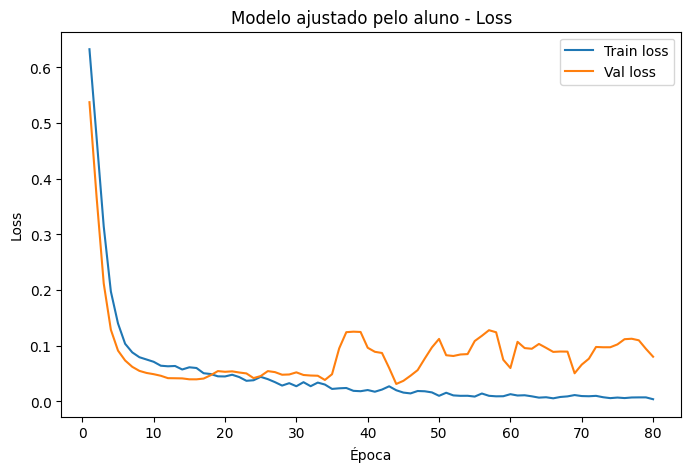

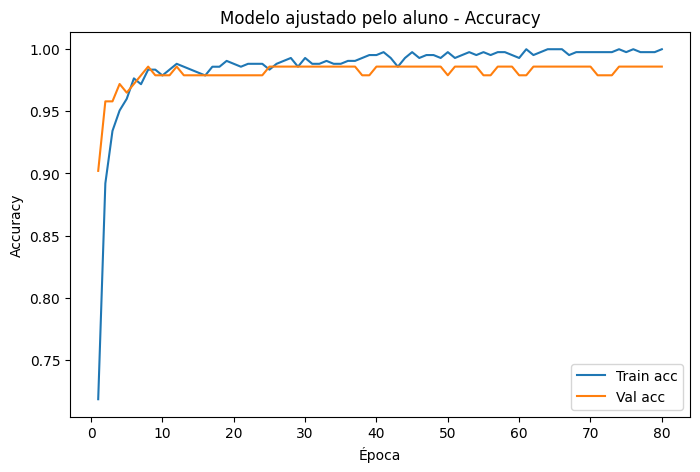

In [12]:
# ÁREA DE INTERVENÇÃO - Aqui você pode testar novas hipóteses para melhorar a generalização do modelo.

class MLPAdjusted(nn.Module):
    def __init__(self, input_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

model_adj = MLPAdjusted(X_train_t.shape[1], dropout=0.2).to(device)
optimizer_adj = torch.optim.Adam(model_adj.parameters(), lr=1e-3, weight_decay=1e-4)

history_adj = fit(model_adj, train_loader, val_loader, criterion, optimizer_adj, epochs=80)
plot_history(history_adj, title="Modelo ajustado pelo aluno")

## Registro comparativo

| Configuração | Train Acc Final | Val Acc Final | Gap | Diagnóstico |
|---|---:|---:|---:|---|
| Exagerada (Drop=0.65) | 97.6% | 97.9% | -0.3% | **Underfitting:** Regularização rígida demais; train_loss alta. |
| Ajuste 1 (Drop=0.2, L2=1e-4) | 100.0% | 98.6% | +1.4% | **Leve Overfitting:** Aprendizado liberto, começou a memorizar o treino. |
| Ajuste 2 (Drop=0.3, L2=1e-3) | 99.5% | 98.6% | +0.9% | **Equilíbrio Ideal:** Um bom trade-off na generalização e menor gap. |

## Conclusão
**Regularizar demais** (como usar Dropout de 65% e L2 altíssimo) prejudica drasticamente a capacidade expressiva e representativa da rede neural. Durante o treinamento, a maior parte da ativação é desativada e os pesos são tão severamente punidos que o modelo não consegue extrair nem mapear as dependências mais básicas do conjunto de treino (resultando em *underfitting*). Em vez de combater a extrema memorização, a hiper-restrição 'sabota' a capacidade genuína de aprendizado da arquitetura.